# 04 · Live fast mode mapping on the instrument (paper Fig. 4)

Two probes, same protocol: an equispaced design measured in one pass, reconstructed
afterwards by a rank-r Chebyshev fit, and scored on a **separate capture** of positions
the design never visited (measured within the hour).

| probe | design | validation | reported |
|---|---|---|---|
| PPP-CONTAu (5 modes) | 12 pos, 13.8 min | 15 pos | 0.169 NRMSE, 98 % < 3 dB at rank 8 |
| SCM-PIT-B R2 (3 modes) | 8 pos, ~9 min | 7 midpoints | 0.19 NRMSE, 93 % < 3 dB at rank 5 |

The SCM-PIT-B numbers in the campaign reports came from a re-implementation (SVD + spline)
because scipy was missing on the instrument VM. Here both probes go through
`activemodemap.lowrank`, which is the Phase-2b re-score.

In [1]:
%matplotlib inline
import sys, pathlib
# make the paper package importable when running from notebooks/
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fmmpaper as F
from fmmpaper import io, axis, spectra, domains, recon, plotting as fp, results
fp.setup()
print(F.config.describe())

project : /home/claude/work/paper_analysis
data_root: /mnt/user-data/uploads/ActiveModeMap  (ok)
amm_repo : /home/claude/work  (ok)
eb_repo  : C:\Users\lz1\Documents\Github\EB-Solver-CResonance  (MISSING)
fmm_code_zip: /mnt/user-data/uploads/ActiveModeMap_repo/Manuscript_FMM/FMM_analysis_code.zip  (ok)


In [2]:
cases = {
    "PPP-CONTAu": ("ppp_wb_fast", "ppp_wb_valid", range(4, 12)),
    "SCM-PIT-B R2": ("scmpitB_r2_wb_fast", "scmpitB_r2_wb_valid", range(3, 8)),
}
if (F.config.data_root() / F.registry.DATASETS["scmpitB_r1_wb_fast"].path).exists():
    cases["SCM-PIT-B R1"] = ("scmpitB_r1_wb_fast", "scmpitB_r1_wb_valid", range(3, 8))

rows, keep = [], {}
for name, (kd, kv, ranks) in cases.items():
    d, v = F.load(kd), F.load(kv)
    assert np.allclose(d.freq_Hz, v.freq_Hz)
    for r in ranks:
        Zp, sd = recon.cross_capture(d.x_um, d.Z[0], v.x_um, arm="lowrank", rank=r)
        sc = recon.score(Zp, v.Z[0], d.freq_Hz, bands=d.probe.bands_Hz)
        rows.append(dict(probe=name, rank=r, N=len(d.x_um), **sc))
        keep[(name, r)] = (d, v, Zp)
live = pd.DataFrame(rows)
live.round(3)

,probe,rank,N,nrmse,nrmse_amp,db_median,within_3dB,phase_mae_deg,nrmse_CR1,nrmse_CR2,nrmse_CR3,nrmse_CR4,nrmse_CR5
0,PPP-CONTAu,4,12,53.209,48.882,3.193,0.491,22.423,9.187,10.262,42.107,80.670,83.498
1,PPP-CONTAu,5,12,40.213,35.188,1.077,0.666,13.412,9.393,8.129,21.667,43.840,79.249
2,PPP-CONTAu,6,12,24.193,19.675,0.629,0.843,4.762,9.887,6.393,15.146,33.031,40.873
3,PPP-CONTAu,7,12,20.842,15.657,0.565,0.911,4.162,9.977,6.874,13.688,23.749,37.600
4,PPP-CONTAu,8,12,16.941,10.172,0.435,0.978,4.101,10.277,7.048,13.705,22.823,25.020
5,PPP-CONTAu,9,12,17.871,10.452,0.414,0.976,4.344,10.267,7.842,14.167,26.677,24.212
6,PPP-CONTAu,10,12,18.564,10.881,0.456,0.972,4.630,10.815,8.121,14.239,26.792,26.182
7,PPP-CONTAu,11,12,22.923,14.485,0.543,0.944,5.636,17.673,10.316,14.733,27.799,34.585
8,SCM-PIT-B R2,3,8,37.272,34.714,2.137,0.583,4.302,9.968,39.587,46.975,NaN,NaN
9,SCM-PIT-B R2,4,8,29.562,24.172,0.776,0.783,7.959,11.323,17.004,46.937,NaN,NaN


In [3]:
best = live.loc[live.groupby('probe').nrmse.idxmin()]
best[['probe', 'N', 'rank', 'nrmse', 'db_median', 'within_3dB', 'phase_mae_deg']].round(3)

,probe,N,rank,nrmse,db_median,within_3dB,phase_mae_deg
4,PPP-CONTAu,12,8,16.941,0.435,0.978,4.101
15,SCM-PIT-B R1,8,5,24.888,0.545,0.940,5.158
10,SCM-PIT-B R2,8,5,19.055,0.395,0.989,3.368


## R1 vs R2 on a matched span, in the lever frame (Phase 2b)

The R2 report partly attributed R2's better wideband score to a shorter span ("R2's pre-flight
stopped 20 µm earlier"). In stage coordinates R2 starts at 72 µm, against 52 µm for R1. But the
clamp was at x₀ = 5.95 µm during R1's wideband stage and 23.95 µm during R2's (notebook 05a).
In the lever frame both runs start at 46–48 µm, and it is R2 that stops 18 µm short of the tip
(208 vs 226 µm).

The fair test keeps all 8 design positions and scores only validation positions inside the shared
lever span. Dropping design points instead would confound span with N. Validation positions use
x₀ at the validation stage, which is 2.75 µm (R1) and 1.1 µm (R2) later than the design stage.

In [4]:
import datetime as dt
from fmmpaper import calib
CAMP = {"R1": ("DomainsB_SCMPIT", dt.datetime(2026, 9, 20, 11)),
        "R2": ("DomainsB_SCMPIT_R2", dt.datetime(2026, 9, 20, 22))}
X0 = {}
for t, (c, d0) in CAMP.items():
    a = calib.frame_anchors(c, calib.timeline(c, d0), 226.5).set_index("stage")
    X0[t] = (float(a.loc["20_wideband_fast", "x0"]), float(a.loc["21_wideband_validation", "x0"]))
runs = {t: (F.load(f"scmpitB_{t.lower()}_wb_fast"), F.load(f"scmpitB_{t.lower()}_wb_valid"))
        for t in CAMP if (F.config.data_root() / F.registry.DATASETS[f"scmpitB_{t.lower()}_wb_fast"].path).exists()}
lo = max(d.x_um.min() - X0[t][0] for t, (d, v) in runs.items())
hi = min(d.x_um.max() - X0[t][0] for t, (d, v) in runs.items())
print({t: tuple(round(x, 2) for x in v) for t, v in X0.items()}, f"shared lever span {lo:.1f}-{hi:.1f} um")
rows = []
for t, (d, v) in runs.items():
    xd, xv = d.x_um - X0[t][0], v.x_um - X0[t][1]
    for frame, xdd, xvv in (("stage", d.x_um, v.x_um), ("lever", xd, xv)):
        for tag, mv in (("all validation", np.ones(len(xv), bool)),
                        ("shared span only", (xv >= lo) & (xv <= hi))):
            for r in (4, 5, 6):
                Zp, _ = recon.cross_capture(xdd, d.Z[0], xvv[mv], arm="lowrank", rank=r)
                sc = recon.score(Zp, v.Z[0][mv], d.freq_Hz, bands=d.probe.bands_Hz)
                rows.append(dict(run=t, frame=frame, scored=tag, n_valid=int(mv.sum()), rank=r,
                                 **{k: sc[k] for k in ("nrmse", "within_3dB", "phase_mae_deg",
                                                       "nrmse_CR1", "nrmse_CR2", "nrmse_CR3")}))
matched = pd.DataFrame(rows)
matched.pivot_table(index=["frame", "scored", "rank"], columns="run",
                    values=["nrmse", "nrmse_CR3"]).round(1)

{'R1': (5.95, 8.7), 'R2': (23.95, 25.05)} shared lever span 48.0-208.0 um


nrmse       nrmse_CR3      
run                            R1    R2        R1    R2
frame scored           rank                            
lever all validation   4     41.6  29.1      69.4  46.1
                       5     26.8  18.9      39.3  22.9
                       6     26.8  20.0      37.2  26.9
      shared span only 4     41.6  29.1      77.1  46.1
                       5     26.8  18.9      43.2  22.9
                       6     26.8  20.0      40.1  26.9
stage all validation   4     41.2  29.6      70.0  46.9
                       5     24.9  19.1      36.4  23.1
                       6     25.6  20.3      35.9  27.3
      shared span only 4     41.5  29.6      78.1  46.9
                       5     24.4  19.1      38.3  23.1
                       6     25.0  20.3      36.9  27.3

**Reading.**
- Correcting for the clamp moving between the design and validation captures changes the
  error by less than 2 points. At 23–26 µm spacing this correction is negligible.
- On the shared span R1 is still worse: 26.8 % vs 18.9 % at rank 5. R1's two tip-end validation
  positions are its best (21 %), not its worst.
- **The span confound is withdrawn.** R2 reconstructs better because of the contact state, not
  the span. The gap is almost all CR3 (43 % vs 23 %), consistent with R2's higher CR3 Q
  (271 vs 138, notebook 03a) after the R1 load ladder changed the tip (notebook 05a).
- The package-backed numbers agree with the report's re-implementation to within 1–2 points
  (R1 26.5 %, R2 19.3 % at rank 5).

[PosixPath('/home/claude/work/paper_analysis/figures/04_live_fmm.png'),
 PosixPath('/home/claude/work/paper_analysis/figures/04_live_fmm.pdf')]

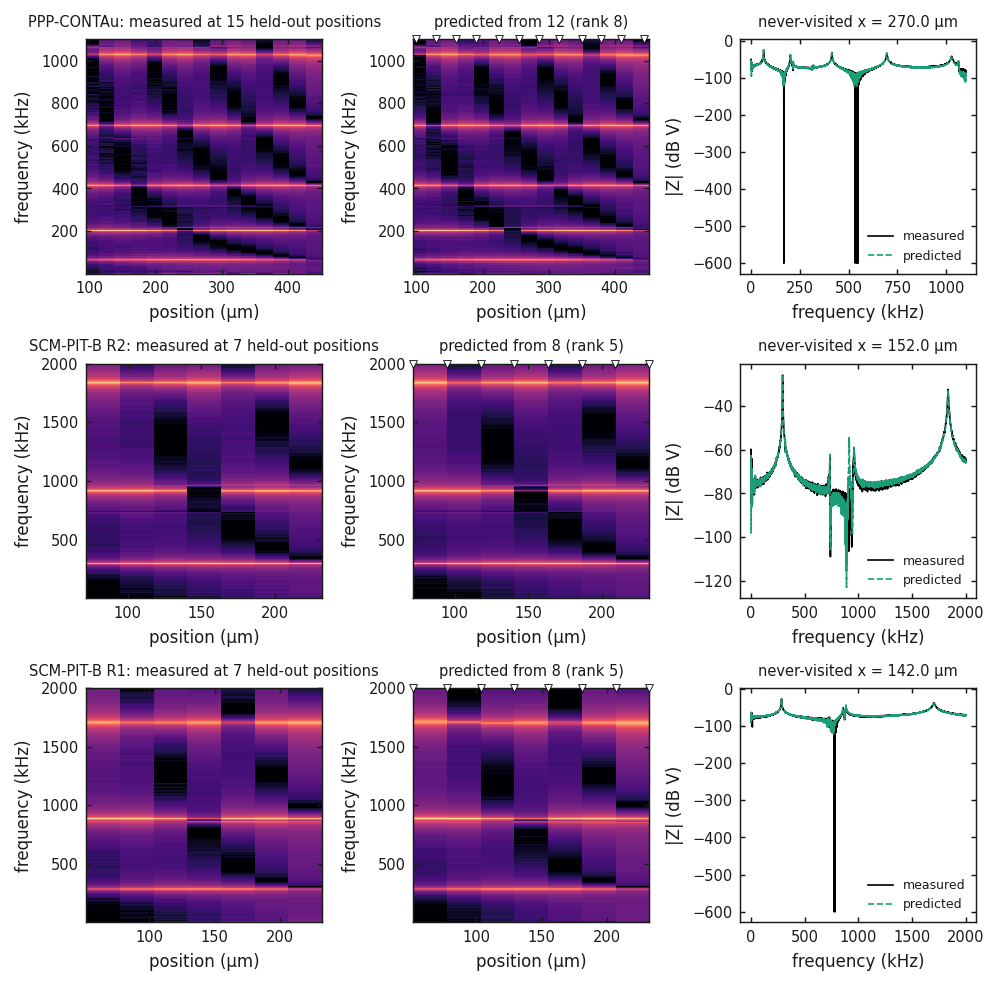

In [5]:
fig, axs = plt.subplots(len(cases), 3, figsize=(fp.WIDTH_IN['double'], 2.2 * len(cases)))
axs = np.atleast_2d(axs)
for row, name in enumerate(cases):
    b = best.query("probe == @name").iloc[0]
    d, v, Zp = keep[(name, int(b['rank']))]
    ref = np.abs(v.Z[0]).max()
    fp.map_db(axs[row, 0], v.x_um, v.freq_Hz, v.Z[0], ref=ref, colorbar=False)
    axs[row, 0].set_title(f"{name}: measured at {len(v.x_um)} held-out positions", fontsize=7)
    fp.map_db(axs[row, 1], v.x_um, v.freq_Hz, Zp, ref=ref, colorbar=False)
    fp.mark_positions(axs[row, 1], d.x_um)
    axs[row, 1].set_title(f"predicted from {len(d.x_um)} (rank {int(b['rank'])})", fontsize=7)
    j = len(v.x_um) // 2
    fp.spectrum(axs[row, 2], v.freq_Hz, v.Z[0, j], label='measured', db=True, lw=0.8)
    fp.spectrum(axs[row, 2], v.freq_Hz, Zp[j], label='predicted', color=fp.C['lowrank'], db=True, lw=0.8, ls='--')
    axs[row, 2].set_title(f"never-visited x = {v.x_um[j]:.1f} µm", fontsize=7)
    axs[row, 2].set_ylabel("|Z| (dB V)"); axs[row, 2].legend(fontsize=6)
fig.tight_layout(); fp.save(fig, "04_live_fmm")

PosixPath('/home/claude/work/paper_analysis/results/fig4_live_fmm.json')

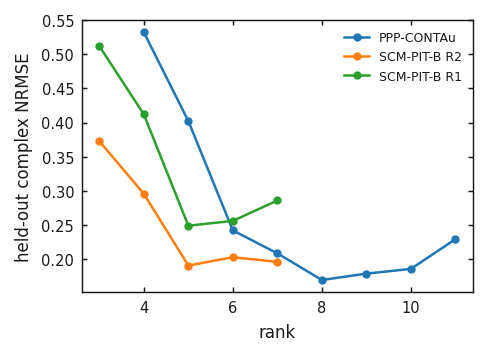

In [6]:
fig, ax = fp.figure("single", aspect=0.7)
for name in cases:
    d = live.query("probe == @name")
    ax.plot(d['rank'], d.nrmse / 100, 'o-', ms=3, label=name)
ax.set_xlabel("rank"); ax.set_ylabel("held-out complex NRMSE"); ax.legend(fontsize=6)
fp.save(fig, "04_error_vs_rank")
results.save("fig4_live_fmm", {r.probe: dict(rank=int(r['rank']), nrmse=r.nrmse, within_3dB=r.within_3dB,
                                              phase_mae_deg=r.phase_mae_deg) for _, r in best.iterrows()},
             table=live)